# PSE-823: Advanced Process Dynamics and Control
## Lecture 4 -- Second-Order Systems, Transportation Lag and the Control System
### (Coughanowr & LeBlanc, Ch. 7-8)

Date: __________

## Agenda

**Part A** -- The manometer: an inherently second-order system (Sec. 7.1)

**Part B** -- Reading an underdamped response: overshoot, decay ratio,
period (Sec. 7.1)

**Part C** -- Transportation lag and its Pade approximations (Sec. 7.2)

**Part D** -- The control system: the stirred-tank heater as a block
diagram (Ch. 8)

### Setup (run once)

- The standard imports, as in Lecture 3
- In Colab, run `%pip install control` first

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})

## Part A
### The Manometer: an Inherently Second-Order System

(Coughanowr & LeBlanc, Ch. 7, Sec. 7.1)
<!-- source: coughanowr-ch7 -->

### Introduce -- why does a manometer reading oscillate? (Fig. 7-1)

- A U-tube, liquid column of length $L$, tube diameter $D$.
- At $t = 0$ a pressure difference $\Delta P$ is applied.
- The liquid has **inertia** and **friction**: it can overshoot.
- Assumptions: laminar flow; Hagen-Poiseuille friction at every
  instant; momentum correction $\beta = 4/3$.

*Textbook figure: Coughanowr Fig. 7-1 (manometer).*

### Derive 1/3 -- the force balance (Eq. 7.3)

Rate of change of momentum = pressure force $-$ weight $-$ wall friction; interface velocity $\bar V = \frac12 \frac{dh}{dt}$:

$$\rho\frac{\pi D^2}{4}L\cdot\frac43\cdot\frac12\ddot h
= \Delta P\frac{\pi D^2}{4} - \rho gh\frac{\pi D^2}{4}
- \frac{8\mu}{D}\cdot\frac12\dot h\cdot\pi DL$$

### Derive 2/3 -- standard form

Divide by $\rho g\,\pi D^2/4$:

$$\underbrace{\frac{2L}{3g}}_{\tau^2}\ddot h +
\underbrace{\frac{16\mu L}{\rho D^2 g}}_{2\zeta\tau}\dot h + h
= \frac{\Delta P}{\rho g}
\;\Rightarrow\;
\tau = \sqrt{\frac{2L}{3g}},\quad
\zeta = \frac{8\mu}{\rho D^2}\sqrt{\frac{3L}{2g}}$$

### Derive 3/3 -- transfer function and its roots

Zero initial conditions, Laplace transform:

$$\frac{Y(s)}{X(s)} = \frac{1}{\tau^2s^2 + 2\zeta\tau s + 1}
\qquad (7.12)$$

Roots $s = \left(-\zeta \pm \sqrt{\zeta^2 - 1}\right)/\tau$:
complex if $\zeta < 1$ (underdamped), equal if $\zeta = 1$
(critical), real if $\zeta > 1$ (overdamped). Table 7.1.

### Code 1/3 -- from force balance to $\tau$ and $\zeta$

- Mirrors Derive 1/3-2/3: divide the balance, match coefficients
- `sp.solve` on two equations returns $\tau$ and $\zeta$ together

In [2]:
L, g, mu, rho, D = sp.symbols("L g mu rho D", positive=True)
tau, zeta = sp.symbols("tau zeta", positive=True)
a2 = sp.Rational(2, 3) * L / g                 # coefficient of h''
a1 = 16 * mu * L / (rho * D**2 * g)            # coefficient of h'
sol = sp.solve([sp.Eq(tau**2, a2), sp.Eq(2*zeta*tau, a1)],
               [tau, zeta], dict=True)[0]
sol

{tau: sqrt(6)*sqrt(L)/(3*sqrt(g)),
 zeta: 4*sqrt(6)*sqrt(L)*mu/(D**2*sqrt(g)*rho)}

**Code walkthrough.** `a2` and `a1` are the two coefficients of Eq. 7.4 after dividing by
rho g pi D^2/4 (Derive 2/3). Matching them to tau^2 and 2 zeta tau gives
two equations in two unknowns; `sp.solve(..., dict=True)[0]` returns a
dictionary. Because tau and zeta were declared positive, SymPy keeps
only the physical root: tau = sqrt(6) sqrt(L/g)/3, which is
sqrt(2L/(3g)), and zeta = 4 sqrt(6) mu sqrt(L/g)/(rho D^2), which is
(8 mu/(rho D^2)) sqrt(3L/(2g)): Eqs. 7.9 and 7.10.

### Code 2/3 -- the book's three manometers

- Water, $L = 200$ cm, three tube diameters (cgs units)
- Substitute the numbers into the formulas from Code 1/3

In [3]:
data = {L: 200, g: 980, mu: 0.01, rho: 1.0}       # cm, g, s
for Dv in [0.11, 0.21, 0.31]:                      # cm
    tv = float(sol[tau].subs(data))
    zv = float(sol[zeta].subs(data | {D: Dv}))
    print(f"D = {Dv} cm: tau = {tv:.3f} s, zeta = {zv:.2f}")

D = 0.11 cm: tau = 0.369 s, zeta = 3.66
D = 0.21 cm: tau = 0.369 s, zeta = 1.00
D = 0.31 cm: tau = 0.369 s, zeta = 0.46


**Code walkthrough.** `data` holds the book's values in cgs units. `data | {D: Dv}` merges two
dictionaries (Python 3.9+), adding the diameter. Each line prints tau =
0.369 s (it does not depend on D) and zeta = 3.66, 1.00, 0.46 for the
three tubes, the book's table. A thinner tube means more friction per
unit of liquid, so more damping.

### Code 3/3 -- the roots decide the case

- Mirrors Derive 3/3: roots of $\tau^2s^2 + 2\zeta\tau s + 1$
- `np.iscomplex` tells underdamped from overdamped

In [4]:
tv = 0.369
for zv in [3.66, 1.00, 0.46]:
    r = np.roots([tv**2, 2 * zv * tv, 1])
    kind = "complex" if np.iscomplex(r).any() else "real"
    print(f"zeta = {zv}: roots {np.round(r, 2)} ({kind})")

zeta = 3.66: roots [-19.46  -0.38] (real)
zeta = 1.0: roots [-2.71 -2.71] (real)
zeta = 0.46: roots [-1.25+2.41j -1.25-2.41j] (complex)


**Code walkthrough.** `np.roots` takes the denominator coefficients highest power first. For
zeta = 3.66 the roots are real and far apart (-19.46, -0.38): an
overdamped system that behaves like two first-order lags in series
(Eq. 7.22). For zeta = 1.00 they are real and equal, -2.71 twice: critically
damped. For 0.46 they are complex, -1.25 +/- 2.41j:
underdamped. The imaginary part 2.41 rad/s is the oscillation
frequency of Eq. 7.27.

### Build on it -- the step responses (cf. Fig. 7-5)

- One `ct.tf` per manometer, a 10 cm step; no inversion by hand

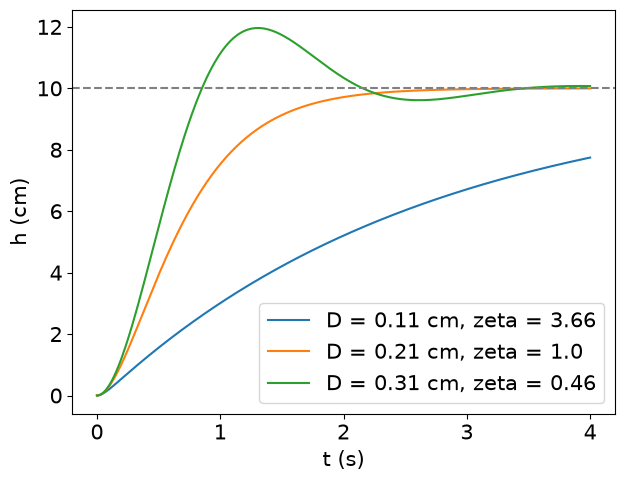

In [5]:
tt = np.linspace(0, 4, 400)                         # s
fig, ax = plt.subplots(figsize=(7, 5.25))
for Dv, zv in [(0.11, 3.66), (0.21, 1.00), (0.31, 0.46)]:
    G = ct.tf([1], [tv**2, 2 * zv * tv, 1])
    y = ct.step_response(10 * G, tt).outputs        # 10 cm step
    ax.plot(tt, y, label=f"D = {Dv} cm, zeta = {zv}")
ax.axhline(10, ls="--", c="gray")
ax.set(xlabel="t (s)", ylabel="h (cm)")
ax.legend(loc="lower right")
plt.show()

**Code walkthrough.** Each pass builds the transfer function 1/(tau^2 s^2 + 2 zeta tau s + 1)
and simulates a 10 cm step (`10 * G` scales the input). The thinnest
tube creeps up slowly (overdamped); the middle one rises fastest without
overshoot (critically damped); the widest overshoots to about 12 cm and
rings before settling (underdamped). The practical fix for the last one
is a snubber -- a restriction that raises the friction, i.e. zeta.

### Your Turn (8 min)

1. By hand: same water manometer, $D = 0.25$ cm. Find $\zeta$
   ($\zeta = 0.0443/D^2$). Under-, critically or overdamped?
2. Read the code: real or complex? (No need for the numbers.)

```python
print(np.roots([0.136, 0.340, 1]))
```

(1) zeta = 0.0443/0.0625 = 0.71: underdamped (slightly).
(2) Complex: 0.136 = tau^2 and 0.340 = 2 zeta tau with zeta = 0.46 --
the D = 0.31 cm manometer of the book. The discriminant 0.340^2 -
4(0.136) < 0 settles it without computing roots: -1.25 +/- 2.41j.

### Check -- cold-call

A **snubber** is a partly closed valve placed in the bend of the tube.
Which parameter does it change -- $\tau$ or $\zeta$ -- and in which
direction? Why does that make the gauge easier to read?

zeta, upward: it adds friction (like a larger mu in Eq. 7.10). tau =
sqrt(2L/3g) does not involve friction. Less oscillation means a steady
reading sooner.

## Part B
### Reading an Underdamped Response

(Coughanowr & LeBlanc, Ch. 7, Sec. 7.1)
<!-- source: coughanowr-ch7 -->

### Introduce -- numbers that describe a wiggle (Fig. 7-6)

- **Overshoot** $A/B$; **decay ratio** $C/A$; **period** $T$;
  **rise time** $t_r$ (first reaching the final value);
  **response time** (within $\pm 5\%$ for good).
- Why care: a reactor temperature may not exceed a catalyst limit;
  a tank may not overflow.
- Unit step response for $\zeta < 1$ (Eq. 7.18):

$$Y = 1 - \frac{e^{-\zeta t/\tau}}{\sqrt{1-\zeta^2}}
\sin\!\left(\sqrt{1-\zeta^2}\,\frac{t}{\tau}
+ \tan^{-1}\frac{\sqrt{1-\zeta^2}}{\zeta}\right)$$

### Derive 1/3 -- where are the peaks?

Differentiate Eq. 7.18 and set $dY/dt = 0$:

$$\frac{dY}{dt} = \frac{e^{-\zeta t/\tau}}{\tau\sqrt{1-\zeta^2}}
\sin\!\left(\sqrt{1-\zeta^2}\,\frac{t}{\tau}\right) = 0
\;\Rightarrow\; t_p = \frac{\pi\tau}{\sqrt{1-\zeta^2}}$$

### Derive 2/3 -- overshoot and decay ratio

Evaluate $Y(t_p) - 1$; the next peak is one period later:

$$\text{overshoot} = \exp\!\left(\frac{-\pi\zeta}{\sqrt{1-\zeta^2}}\right)
\;(7.25), \qquad
\text{decay ratio} = (\text{overshoot})^2 \;(7.26)$$

### Derive 3/3 -- period of oscillation

The coefficient of $t$ inside the sine is the radian frequency:

$$\omega = \frac{\sqrt{1-\zeta^2}}{\tau}\;(7.27), \qquad
T = \frac{2\pi\tau}{\sqrt{1-\zeta^2}}\;(7.28)$$

At $\zeta = 0$: the natural period $T_n = 2\pi\tau$.

### Code 1/3 -- differentiate Eq. 7.18

- Mirrors Derive 1/3: type Eq. 7.18, let SymPy differentiate
- Declaring $0 < \zeta$ lets the simplification go through

In [6]:
t = sp.symbols("t", positive=True)
wd = sp.sqrt(1 - zeta**2)                     # damped frequency * tau
Y = 1 - sp.exp(-zeta*t/tau) / wd * sp.sin(wd*t/tau + sp.atan(wd/zeta))
dY = sp.simplify(sp.diff(Y, t))
dY

exp(-t*zeta/tau)*sin(t*sqrt(1 - zeta**2)/tau)/(tau*sqrt(1 - zeta**2))

**Code walkthrough.** `wd` is sqrt(1 - zeta^2), reused three times. `Y` is Eq. 7.18 typed as
on the slide. `sp.diff` differentiates and `sp.simplify` combines the
product rule's two terms using sin/cos identities. The result is
exp(-t zeta/tau) sin(t sqrt(1 - zeta^2)/tau)/(tau sqrt(1 - zeta^2)):
Derive 1/3. It is zero where the sine is zero, i.e. at t = n pi tau/wd.

### Code 2/3 -- overshoot from the formula

- Mirrors Derive 2/3: substitute the first peak time into $Y - 1$

In [7]:
tp = sp.pi * tau / wd                          # first peak
overshoot = sp.simplify(Y.subs(t, tp) - 1)
print(overshoot)                               # Eq. 7.25
print(sp.simplify(overshoot**2))               # Eq. 7.26

exp(-pi*zeta/sqrt(1 - zeta**2))
exp(-2*pi*zeta/sqrt(1 - zeta**2))


**Code walkthrough.** `Y.subs(t, tp) - 1` is the peak minus the final value, i.e. A in Fig. 7-6
for a unit step. SymPy simplifies it to exp(-pi zeta/sqrt(1 - zeta^2)),
Eq. 7.25. The decay ratio C/A compares the second peak (at 3 t_p, one
period later) with the first; algebraically it is the square of the
overshoot, Eq. 7.26, printed on the last line.

### Code 3/3 -- Prob. 7.1 by formula and by simulation

- $Y/X = 10/(s^2 + 1.6s + 4) = 2.5/(0.25s^2 + 0.4s + 1)$: $\tau = 0.5$, $\zeta = 0.4$
- Step of 4; `ct.step_info` measures the simulated response

In [8]:
tv, zv, K, M = 0.5, 0.4, 2.5, 4.0
os_ = np.exp(-np.pi * zv / np.sqrt(1 - zv**2))       # Eq. 7.25
T = 2 * np.pi * tv / np.sqrt(1 - zv**2)              # Eq. 7.28
print(f"formula:  max {K*M*(1 + os_):.2f}, period {T:.2f}")
info = ct.step_info(M * ct.tf([10], [1, 1.6, 4]))
print(f"measured: max {info['Peak']:.2f}, "
      f"peak at {info['PeakTime']:.2f}")

formula:  max 12.54, period 3.43
measured: max 12.53, peak at 1.74


**Code walkthrough.** Rewriting the denominator with a 1 as the constant term gives tau^2 =
0.25 and 2 zeta tau = 0.4, so tau = 0.5 and zeta = 0.4; the gain is
10/4 = 2.5 and the ultimate value is 2.5 x 4 = 10. Formula: overshoot
0.254, maximum 12.54, period 3.43 (time units of the problem).
`ct.step_info` simulates and measures: peak 12.53 at t = 1.74, which is
half the period, t_p = T/2. Note `step_info`'s RiseTime is the 10-90%
time, not the book's t_r.

### Build on it -- a damping-ratio sweep (cf. Fig. 7-3)

- Plot $Y$ against $t/\tau$ for six values of $\zeta$

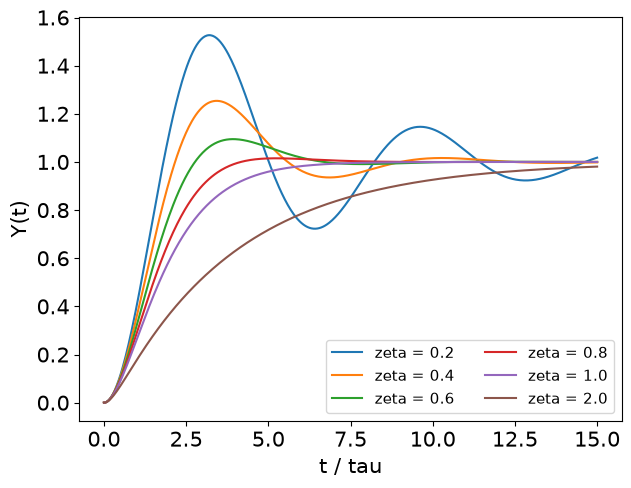

In [9]:
tt = np.linspace(0, 15, 500)                        # t / tau
fig, ax = plt.subplots(figsize=(7, 5.25))
for zv in [0.2, 0.4, 0.6, 0.8, 1.0, 2.0]:
    y = ct.step_response(ct.tf([1], [1, 2*zv, 1]), tt).outputs
    ax.plot(tt, y, label=f"zeta = {zv}")
ax.set(xlabel="t / tau", ylabel="Y(t)")
ax.legend(loc="lower right", ncol=2, fontsize=11)
plt.show()

**Code walkthrough.** With tau = 1, time is already t/tau, so one set of curves serves every
second-order system: the book's Fig. 7-3. Small zeta: large overshoot,
long ringing. zeta = 1: the fastest approach without overshoot. zeta = 2:
sluggish. All curves start with zero slope -- a second-order system
never jumps at t = 0.

### Your Turn (8 min)

**Prob. 7.15.** $Y/X = 10/(2s^2 + 0.3s + 0.5)$, step of 3.

1. By hand: standard form, $\tau$, $\zeta$, overshoot and the
   radian frequency of oscillation.
2. Read the code: what does this print, to two decimals?

```python
print(np.exp(-np.pi * 0.15 / np.sqrt(1 - 0.15**2)))
```

(1) Divide by 0.5: 20/(4 s^2 + 0.6 s + 1). tau = 2, 2 zeta tau = 0.6 so
zeta = 0.15. Overshoot = exp(-pi 0.15/0.989) = 0.62; omega =
sqrt(1 - 0.0225)/2 = 0.494 rad/time. Ultimate value 20 x 3 = 60; peak
60(1.62) = 97.3.
(2) 0.62: the overshoot of part 1.

### Check -- poll

You may not overshoot at all, but want the **fastest** approach to the
new value. Which $\zeta$ do you choose?

**A)** 0.4  **B)** 0.7  **C)** 1.0  **D)** 2.0

C, critical damping: "the most rapid approach ... without oscillation"
(Sec. 7.1). B is the common practical compromise when a small overshoot
(about 5%) is acceptable in exchange for speed.

## Part C
### Transportation Lag and its Pade Approximations

(Coughanowr & LeBlanc, Ch. 7, Sec. 7.2)
<!-- source: coughanowr-ch7 -->

### Introduce -- liquid in a pipe (Fig. 7-9)

- Plug flow through an insulated pipe, volume $AL$, flow $q$.
- Whatever enters, leaves -- **unchanged but late**:
  $y(t) = x(t - \tau)$, $\tau = AL/q$.
- Also called **dead time**. It makes control hard (Ch. 16-17).

### Derive 1/2 -- the transfer function of a delay

Translation theorem (App. 3A): $\mathcal{L}\{X(t-\tau)\} = e^{-\tau s}X(s)$:

$$\frac{Y(s)}{X(s)} = e^{-\tau s} \qquad (7.46)$$

Not a ratio of polynomials: Routh (Ch. 13) cannot handle it.

### Derive 2/2 -- rational approximations

Write $e^{-\tau s} = e^{-\tau s/2}/e^{\tau s/2}$ and expand both:

$$e^{-\tau s}\approx\frac{1}{1+\tau s}\;(7.47),\quad
\frac{1-\tau s/2}{1+\tau s/2}\;(7.48),\quad
\frac{1-\frac{\tau s}{2}+\frac{\tau^2s^2}{12}}
{1+\frac{\tau s}{2}+\frac{\tau^2s^2}{12}}\;(7.49)$$

### Code 1/2 -- how many Taylor terms does each match?

- Mirrors Derive 2/2: expand each approximation in powers of $s$
- Subtract the exact series; the first surviving power tells the order

In [10]:
s = sp.symbols("s")
exact = sp.exp(-tau * s)
approx = {"7.47": 1 / (1 + tau*s),
          "7.48": (1 - tau*s/2) / (1 + tau*s/2),
          "7.49": (1 - tau*s/2 + (tau*s)**2/12)
                  / (1 + tau*s/2 + (tau*s)**2/12)}
for name, f in approx.items():
    err = sp.series(f - exact, s, 0, 6).removeO()
    (power,), coeff = sp.Poly(err, s).terms()[-1]   # lowest power
    print(name, "error starts at", coeff * s**power)

7.47 error starts at s**2*tau**2/2
7.48 error starts at -s**3*tau**3/12
7.49 error starts at s**5*tau**5/720


**Code walkthrough.** `sp.series(expr, s, 0, 6)` expands about s = 0 up to s^5;
`.removeO()` drops the order term. Subtracting the exact exponential
leaves only the error. `sp.Poly(err, s).terms()` lists ((power,),
coefficient) pairs from the highest power down, so `[-1]` is the
lowest-order error term; the unpacking `(power,), coeff = ...` names
its two parts. Expected: 7.47 errs at s^2 (tau^2 s^2/2),
7.48 at s^3 (-tau^3 s^3/12), 7.49 at s^5 (tau^5 s^5/720). Each
improvement buys two more matching terms -- why Pade beats a lag.

### Code 2/2 -- `ct.pade` returns the same coefficients

- `ct.pade(T, n)` gives numerator and denominator lists
- Compare with Eqs. 7.48 and 7.49 for $\tau = 2$

In [11]:
for n in [1, 2]:
    num, den = ct.pade(2.0, n)                 # tau = 2
    print(f"order {n}: num {np.round(num, 3)}, "
          f"den {np.round(den, 3)}")

order 1: num [-1.  1.], den [1. 1.]
order 2: num [ 1. -3.  3.], den [1. 3. 3.]


**Code walkthrough.** For tau = 2, Eq. 7.48 is (1 - s)/(1 + s); python-control normalizes the
leading coefficient and returns num [-1, 1], den [1, 1], i.e. (-s + 1)/
(s + 1). Second order: num [1, -3, 3], den [1, 3, 3]; dividing by 3
gives (1 - s + s^2/3)/(1 + s + s^2/3), Eq. 7.49 with tau = 2
(tau^2/12 = 1/3).

### Build on it -- step responses of the approximations (Fig. 7-11)

- The true delay is a shifted step; plot it beside the three

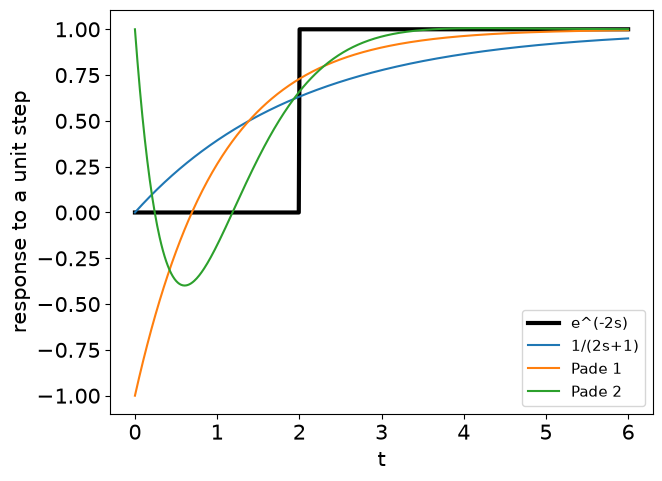

In [12]:
tt = np.linspace(0, 6, 600)
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(tt, (tt >= 2.0).astype(float), "k", lw=3, label="e^(-2s)")
cands = {"1/(2s+1)": ct.tf([1], [2, 1]),
         "Pade 1": ct.tf(*ct.pade(2.0, 1)),
         "Pade 2": ct.tf(*ct.pade(2.0, 2))}
for name, G in cands.items():
    ax.plot(tt, ct.step_response(G, tt).outputs, label=name)
ax.set(xlabel="t", ylabel="response to a unit step")
ax.legend(loc="lower right", fontsize=11)
plt.show()

**Code walkthrough.** `(tt >= 2.0).astype(float)` turns a boolean array into 0/1: the exact
delayed step. `ct.tf(*ct.pade(...))` unpacks the (num, den) pair
straight into a transfer function. Read the plot as the book does: the
first-order lag starts rising at once; first-order Pade jumps to -1 and
then recovers; second-order Pade jumps to +1, dips below 0 and comes
back. None is accurate alone; combined with slower lags (next cell)
they become adequate.

### Build on it -- four tanks look like dead time plus one lag

- Callback to Lecture 3: four noninteracting tanks, $\tau = 1$
- Fit $K e^{-\theta s}/(\tau s + 1)$ (FOPDT) with `curve_fit`

In [13]:
tt = np.linspace(0, 15, 301)
y4 = ct.step_response(ct.tf([1], [1, 1])**4, tt).outputs
def fopdt(t, K, tau_f, theta):
    return np.where(t > theta,
                    K * (1 - np.exp(-(t - theta) / tau_f)), 0.0)
p, _ = curve_fit(fopdt, tt, y4, p0=[1, 2, 1])
print("K = {:.2f}, tau = {:.2f}, theta = {:.2f}".format(*p))
print(f"worst error {np.abs(fopdt(tt, *p) - y4).max():.3f}")

K = 1.03, tau = 2.60, theta = 1.74
worst error 0.098


**Code walkthrough.** `ct.tf([1], [1, 1])**4` is four identical lags in series, the n = 4
curve of Lecture 3. `fopdt` is the step response of K e^(-theta s)/
(tau s + 1): zero until theta, then a first-order rise; `np.where`
picks the branch for each t. `curve_fit` adjusts K, tau and theta. Fit:
K = 1.03, tau = 2.60, theta = 1.74; worst error about 0.1. Four
parameters' worth of physics squeezed into three numbers -- the
"model reduction as fitting" thread that returns in Ch. 18 (Lecture 10).

### Your Turn (8 min)

1. By hand: water flows at $q = 0.5$ L/s through a pipe of volume
   2 L. Find $\tau$ and write the first-order Pade approximation.
2. Read the code: what are `num` and `den`?

```python
num, den = ct.pade(4.0, 1)
```

(1) tau = 2/0.5 = 4 s. Pade: (1 - 2s)/(1 + 2s).
(2) python-control normalizes the leading coefficient: num = [-1, 0.5],
den = [1, 0.5], i.e. (-s + 0.5)/(s + 0.5) -- the same function divided
through by 2.

### Check -- think-pair-share

The first-order Pade approximation's step response first goes the
**wrong way** (to $-1$). What feature of $(1 - \tau s/2)/(1 + \tau s/2)$
causes that -- and why would a controller find it confusing?

The numerator root at s = +2/tau: a right-half-plane zero (inverse
response). A controller that sees the output move the wrong way acts in
the wrong direction at first. Delays and RHP zeros both limit how
aggressive a feedback loop can be (Lectures 6-8).

## Part D
### The Control System: the Stirred-Tank Heater

(Coughanowr & LeBlanc, Ch. 8)
<!-- source: coughanowr-ch8 -->

### Introduce -- four components, one loop (Fig. 8-1, 8-2)

- **Process:** stirred-tank heater, inlet $T_i$, heat input $q$.
- **Measuring element:** thermocouple, reading $T_m$.
- **Controller:** error $\varepsilon = T_R - T_m$, proportional law.
- **Final control element:** heater (or steam valve).
- **Servo problem:** follow set-point changes. **Regulator problem:**
  reject load changes ($T_i$).

### Derive 1/3 -- the process block (Eq. 8.10)

Energy balance, subtract steady state, deviation variables, transform:

$$Q + wC(T_i' - T') = \rho CV\frac{dT'}{dt}
\;\Rightarrow\;
T'(s) = \frac{1/wC}{\tau s+1}Q(s) + \frac{1}{\tau s+1}T_i'(s)$$

$\tau = \rho V/w$. Two inputs; their effects **add** (superposition).

### Derive 2/3 -- Example 8.1 numbers

1000 L, 200 L/min, water, $T_s = 80$ C, $T_{is} = 60$ C:

$\tau = 5$ min, $\;1/wC = 1/(14\ \text{kW/C})$,
$\;q_s = wC(80 - 60) = 280$ kW.

$T_i$ +10 C: $T' = 10(1 - e^{-t/5})$. $\;Q$ +42 kW:
$T' = 3(1 - e^{-t/5})$. Both: $13(1 - e^{-t/5})$.

### Derive 3/3 -- sensor and controller blocks

Ex. 8.2: thermocouple 90% complete in 45 s, first order:

$$0.9 = 1 - e^{-45/\tau_m} \Rightarrow \tau_m = \frac{45}{\ln 10}
= 19.5\ \text{s} = 0.33\ \text{min}$$

Proportional controller: $Q(s) = K_c\,\varepsilon(s)$, with
$\varepsilon = T_R' - T_m'$ (Eqs. 8.24, 8.27).

### Code 1/3 -- Eq. 8.10 from the balance

- Mirrors Derive 1/3: transformed balance, solved for $T'(s)$
- `sp.apart` with respect to $Q$ separates the two inputs

In [14]:
Qs, Tis, Ts = sp.symbols("Q_s T_is T_s")       # transforms
w, Cp, V, rho_ = sp.symbols("w C V rho", positive=True)
bal = sp.Eq(Qs + w*Cp*(Tis - Ts), rho_*Cp*V*s*Ts)   # Eq. 8.8
Tsol = sp.solve(bal, Ts)[0]
print(sp.collect(sp.expand(Tsol), [Qs, Tis]))

C*T_is*w/(C*V*rho*s + C*w) + Q_s/(C*V*rho*s + C*w)


**Code walkthrough.** `Qs`, `Tis`, `Ts` stand for Q(s), T_i'(s), T'(s). `bal` is Eq. 8.8: the
deviation balance after the transform (initial deviation zero). Solving
for T'(s) and collecting terms in Q and T_i' gives
Q/(C V rho s + C w) + T_i' w/(C V rho s + C w). Dividing numerator and
denominator by wC turns these into (1/wC)/(tau s + 1) and 1/(tau s + 1)
with tau = rho V/w: Eq. 8.10.

### Code 2/3 -- Example 8.1: blocks and superposition

- Mirrors Derive 2/3: two `ct.tf` blocks, one per input
- Responses to each input, and to both, at $t = 5$ min

In [15]:
G_Ti = ct.tf([1], [5, 1])                     # T'/Ti'
G_Q = ct.tf([1 / 14], [5, 1])                 # T'/Q, C per kW
tt = np.linspace(0, 30, 301)
a = ct.step_response(10 * G_Ti, tt).outputs   # Ti +10 C
b = ct.step_response(42 * G_Q, tt).outputs    # Q +42 kW
both = ct.forced_response(ct.tf([1], [5, 1]), tt,
                          10 + 42 / 14).outputs
print(f"t = 5 min: {a[50]:.2f} + {b[50]:.2f} = {both[50]:.2f} C")

t = 5 min: 6.32 + 1.90 = 8.22 C


**Code walkthrough.** `G_Ti` and `G_Q` are the two blocks of Eq. 8.10 with tau = 5 min and
1/wC = 1/14 C per kW. `a` and `b` are the responses to each change
alone. `both` feeds the combined input of Fig. 8-3b (Q/wC + T_i' =
3 + 10 C) through 1/(5s + 1) with `forced_response` and a constant
input. At t = 5 min (index 50): 6.32 + 1.90 = 8.22 C, i.e. 13(1 - e^-1):
the effects add, as superposition promises.

### Code 3/3 -- the thermocouple lags the tank (Ex. 8.3)

- Mirrors Derive 3/3: solve the 90% condition for $\tau_m$
- `ct.series` connects tank and sensor blocks

In [16]:
tm = float(sp.solve(sp.Eq(0.9, 1 - sp.exp(-45 / sp.Symbol("x"))),
                    sp.Symbol("x"))[0]) / 60          # min
G_m = ct.tf([1], [tm, 1])
Tm = ct.step_response(10 * ct.series(G_Ti, G_m), tt).outputs
print(f"tau_m = {tm:.3f} min; at t = 1 min: "
      f"T' = {a[10]:.2f}, Tm' = {Tm[10]:.2f} C")

tau_m = 0.326 min; at t = 1 min: T' = 1.81, Tm' = 1.27 C


**Code walkthrough.** The first statement solves 0.9 = 1 - exp(-45/x) for x (seconds) and
converts to minutes: tau_m = 0.326 min, the book's 0.33. `ct.series(G_Ti,
G_m)` multiplies the blocks: inlet temperature -> tank -> sensor, the
book's Fig. 8-10. At t = 1 min the tank has risen 1.81 C but the
thermocouple reads only 1.27 C: the sensor lags, as Fig. 8-11 shows.

### Build on it -- close the loop (Example 8.4)

- P controller $K_c = 20$ kW/C, set point +5 C
- `ct.feedback(forward, sensor)` is the loop of Fig. 8-16

final T' = 2.94 C (asked for 5 C)


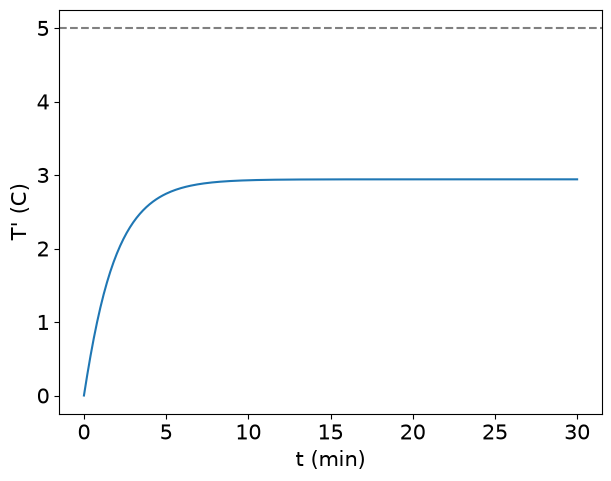

In [17]:
forward = ct.series(ct.tf([20], [1]), G_Q)    # Kc then process
loop = ct.feedback(forward, G_m)              # negative feedback
y = ct.step_response(5 * loop, tt).outputs
print(f"final T' = {y[-1]:.2f} C (asked for 5 C)")
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(tt, y); ax.axhline(5, ls="--", c="gray")
ax.set(xlabel="t (min)", ylabel="T' (C)"); plt.show()

**Code walkthrough.** The forward path is the controller gain 20 kW/C in series with the
heater's T'/Q block. `ct.feedback(forward, G_m)` closes the loop with
the thermocouple in the feedback path and subtracts by default --
negative feedback, Eq. 8.27. This is exactly what the book builds in
Simulink. Prints final T' = 2.94 C for a 5 C set-point change: an
offset of 2.06 C, because the controller is proportional only (Lecture
1, now with real numbers). Ch. 11-12 derive this value by hand.

### Your Turn (8 min)

1. By hand: in Example 8.4, at steady state the sensor reads the true
   temperature. Use $Q = K_c(T_R' - T')$ and $T' = Q/14$ to find the
   final $T'$ for $T_R' = 5$ C.
2. Read the code: what does this print, to two decimals?

```python
print(5 * ct.dcgain(loop))
```

(1) T' = 20(5 - T')/14 -> 14 T' = 100 - 20 T' -> T' = 100/34 = 2.94 C.
Offset 2.06 C.
(2) 2.94: `dcgain` is the closed-loop transfer function at s = 0, the
steady-state gain, times the 5 C step. Same algebra as part 1.

### Check -- cold-call

Example 8.4 changed the set point. If instead $T_i$ drops by 10 C with
the set point fixed, is that a **servo** or a **regulator** problem?
Which transfer function would you need?

Regulator (load change). We need T'/T_i' for the closed loop: the load
block 1/(5s + 1) divided by (1 + Kc G_Q G_m) -- derived in Ch. 11
(next lectures). Most chemical-plant loops are regulators.

### Wrap-up

**Derived, then coded:** the manometer's $\tau$ and $\zeta$; the three
damping cases; overshoot, decay ratio and period; the delay $e^{-\tau s}$
and its Pade approximations; the stirred-tank heater's blocks and the
closed loop of Example 8.4.

**Tools:** `ct.tf`, `ct.step_response`, `ct.step_info`, `ct.pade`,
`ct.series`, `ct.feedback`, `ct.dcgain`, `sp.series`, `curve_fit`

**Next:** Ch. 12-14 -- closed-loop transients, offset, stability and
root locus.